# 02 — External Exposure Paths

> Show every path from an ExternalParty to a regulated asset.

**KQL source:** [`graph-queries/02-external-exposure-paths.kql`](../graph-queries/02-external-exposure-paths.kql)  
**Run it:** click **Run All** above, or `Shift+Enter` through each cell.

## 1. Setup

In [1]:
import subprocess, json, os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

WORKSPACE_ID = os.environ.get("BIGID_GRAPH_WORKSPACE_ID", "77429a58-865a-4764-8429-aaacdfe3cb73")
KQL_FILE = Path("../graph-queries/02-external-exposure-paths.kql")
print("Workspace:", WORKSPACE_ID)
print("Query file:", KQL_FILE.name)

Workspace: 77429a58-865a-4764-8429-aaacdfe3cb73
Query file: 02-external-exposure-paths.kql


## 2. Run the KQL graph query

In [2]:
kql = KQL_FILE.read_text()
result = subprocess.run(
    ["az", "monitor", "log-analytics", "query",
     "--workspace", WORKSPACE_ID,
     "--analytics-query", kql, "-o", "json"],
    capture_output=True, text=True
)
if result.returncode != 0:
    print("Query failed:")
    print(result.stderr)
    rows = []
else:
    rows = json.loads(result.stdout) if result.stdout.strip() else []
print(f"{{len(rows)}} rows returned")
df = pd.DataFrame(rows)
df.head(10)

{len(rows)} rows returned


,TableName,assets_count,classification,classifications,external_party,sample_paths
0,PrimaryResult,4,PCI,"[""PCI""]",External-Partner@vendor.com,"[""External-Partner@vendor.com -[CAN_REACH]-> M..."
1,PrimaryResult,4,PCI,"[""PCI""]",auditor@external-firm.com,"[""auditor@external-firm.com -[CAN_REACH]-> Mar..."
2,PrimaryResult,4,PCI,"[""PCI""]",external-auditor@external-firm.com,"[""external-auditor@external-firm.com -[ACCESSE..."
3,PrimaryResult,2,Restricted;Trade Secret,"[""Restricted;Trade Secret""]",auditor@external-firm.com,"[""auditor@external-firm.com -[CAN_REACH]-> s3:..."
4,PrimaryResult,2,PHI;HIPAA,"[""PHI;HIPAA""]",external-auditor@external-firm.com,"[""external-auditor@external-firm.com -[ACCESSE..."
5,PrimaryResult,2,Restricted;Trade Secret,"[""Restricted;Trade Secret""]",External-Partner@vendor.com,"[""External-Partner@vendor.com -[CAN_REACH]-> s..."
6,PrimaryResult,2,PHI;HIPAA,"[""PHI;HIPAA""]",External-Partner@vendor.com,"[""External-Partner@vendor.com -[CAN_REACH]-> E..."
7,PrimaryResult,2,PHI;HIPAA,"[""PHI;HIPAA""]",auditor@external-firm.com,"[""auditor@external-firm.com -[CAN_REACH]-> Emp..."
8,PrimaryResult,2,Restricted;Trade Secret,"[""Restricted;Trade Secret""]",external-auditor@external-firm.com,"[""external-auditor@external-firm.com -[ACCESSE..."
9,PrimaryResult,1,PII,"[""PII""]",External-Partner@vendor.com,"[""External-Partner@vendor.com -[CAN_REACH]-> C..."


## 3. Render the graph

Blue = `external_party`, red = related assets/sources.

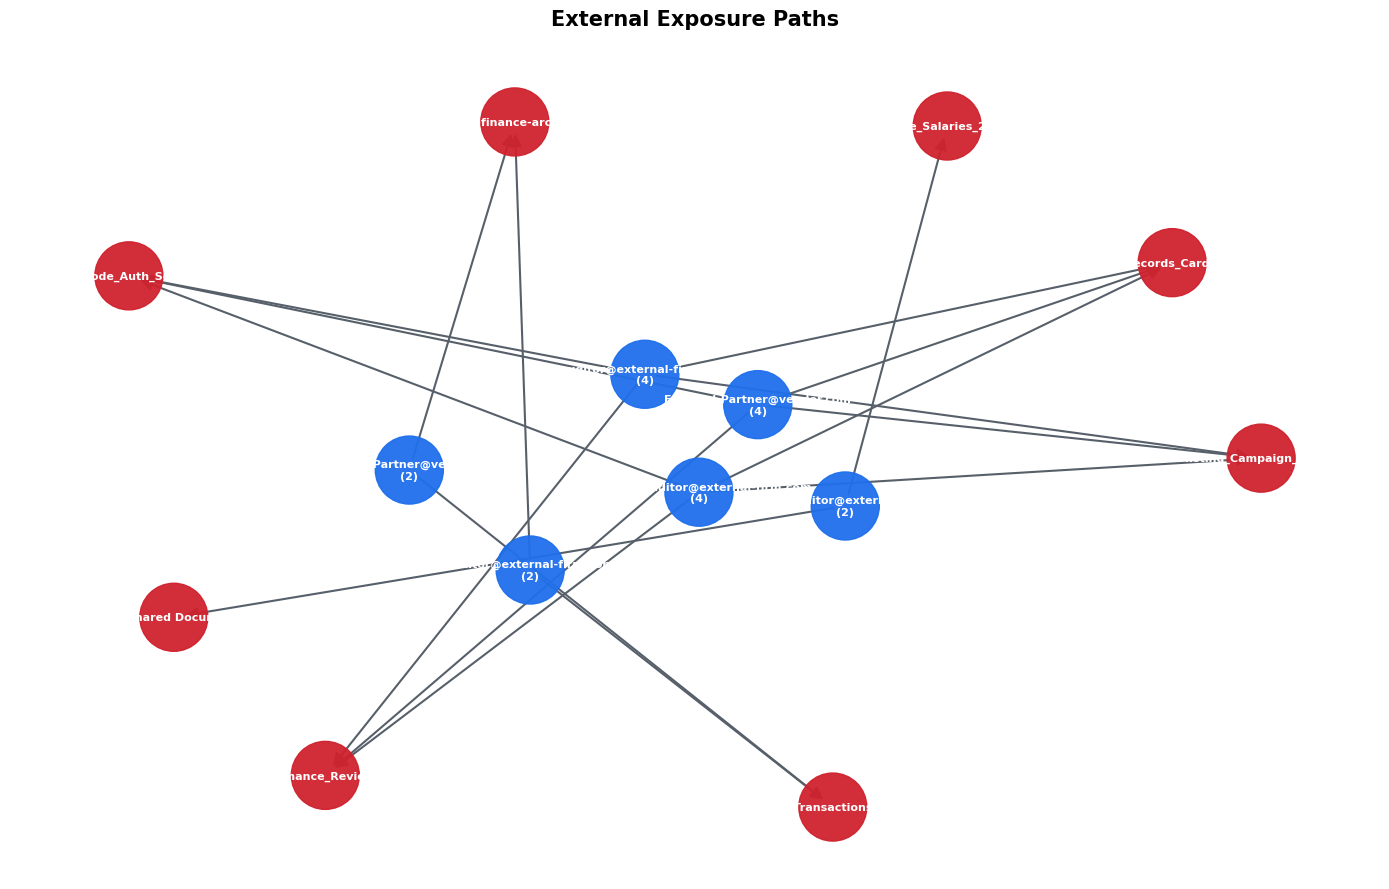

In [3]:
G = nx.DiGraph()
top = rows[:6]
node_colors = {}
COLOR_LEFT = "#1f6feb"
COLOR_RIGHT = "#cf222e"

for r in top:
    left = str(r.get("external_party", ""))[:38]
    weight = r.get("assets_count", 0)
    left_label = f"{left}\n({weight})"
    G.add_node(left_label)
    node_colors[left_label] = COLOR_LEFT
    rights = r.get("sample_paths") or []
    if isinstance(rights, str):
        try: rights = json.loads(rights)
        except: rights = [rights]
    for rt in rights[:4]:
        rt_s = str(rt)
        if "-> " in rt_s:
            rt_s = rt_s.split("-> ")[-1]
        rt_label = rt_s[:36]
        G.add_node(rt_label)
        node_colors[rt_label] = COLOR_RIGHT
        G.add_edge(left_label, rt_label)

fig, ax = plt.subplots(figsize=(14, 9))
pos = nx.spring_layout(G, k=1.8, iterations=80, seed=42)
nx.draw_networkx_nodes(G, pos,
    node_color=[node_colors[n] for n in G.nodes()],
    node_size=2400, alpha=0.95, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="#57606a",
    arrows=True, arrowsize=18, width=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white",
    font_weight="bold", ax=ax)
ax.set_title("External Exposure Paths", fontsize=15, fontweight="bold", pad=18)
ax.axis("off")
plt.tight_layout()
plt.show()